---

# Welcome to Mem0! 🚀

This notebook will guide you through your first API calls with Mem0, the easiest way to give your AI agents real, personalized memory.



Let's get you started in 2 simple steps

*   Paste your API key
*   Click 'Run All' Button shown above

---

In [1]:
# You can find your key on the dashboard.
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("MEM0_API_KEY")
# Note: This key is sensitive. Do not share this notebook with it filled out.

In [3]:
# Install the mem0 Python SDK
# This is the only setup you'll need!

!pip install mem0ai > /dev/null 2>&1

The system cannot find the path specified.


In [4]:
# 🔌 Connect to Mem0 in just one line of code
import time
from mem0 import MemoryClient

client = MemoryClient(api_key=API_KEY)

---

## This is the core of Mem0.

Let's **add some context** from a customer support conversation. This context can be a user's question, a chat message, or any piece of information you want your AI agent to remember.

*Notice how we're simply passing in a message. Mem0 automatically extracts and stores the relevant memories.*

In [5]:
# Define a user ID and a message from that user
user_id = "customer-001"

message_from_user_1 = "My order #1234 was for a 'Nova 2000', but it arrived damaged. It was a gift for my sister."

messages = [
    {"role": "user", "content": message_from_user_1}
]

result = client.add(messages, user_id=user_id, version="v2", output_format="v1.1")
print(result)
time.sleep(10)

{'results': [{'id': '1d6c3a8d-187e-4fc1-ae1f-1e2fa9db238c', 'event': 'ADD', 'memory': 'Order 1234 is for Nova 2000', 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}, {'id': '8fe58c9d-e2de-42bf-8a35-4d9e30ea136e', 'event': 'ADD', 'memory': 'Order 1234 arrived damaged', 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}, {'id': 'a53d1ec3-f0b5-4948-be46-2330286ccbf4', 'event': 'ADD', 'memory': 'Order 1234 was a gift for sister', 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}]}


---

The `add` call's response confirms that the memory was stored.

For immediate visual confirmation, let's make a call to ***fetch all*** memories associated with this user ID.

In [10]:
from mem0 import MemoryClient

client = MemoryClient(api_key=API_KEY)

user_id = "customer-001"

# ✅ Pass filter as direct argument
user_memories = client.get_all(user_id=user_id)

print(user_memories)


[{'id': 'a53d1ec3-f0b5-4948-be46-2330286ccbf4', 'memory': 'Order 1234 was a gift for sister', 'user_id': 'customer-001', 'metadata': None, 'categories': ['family'], 'created_at': '2025-10-18T04:04:21.275935-07:00', 'updated_at': '2025-10-18T04:04:21.301301-07:00', 'expiration_date': None, 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}, {'id': '8fe58c9d-e2de-42bf-8a35-4d9e30ea136e', 'memory': 'Order 1234 arrived damaged', 'user_id': 'customer-001', 'metadata': None, 'categories': ['misc'], 'created_at': '2025-10-18T04:04:21.162547-07:00', 'updated_at': '2025-10-18T04:04:21.185373-07:00', 'expiration_date': None, 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}, {'id': '1d6c3a8d-187e-4fc1-ae1f-1e2fa9db238c'

In [11]:
# filters = {
#    "OR":[
#       {
#          "user_id": user_id
#       }
#    ]
# }

# Fetch all memories for the user_id
# user_memories = client.get_all(filters=filters)

user_memories = client.get_all(user_id=user_id)
print(user_memories)

[{'id': 'a53d1ec3-f0b5-4948-be46-2330286ccbf4', 'memory': 'Order 1234 was a gift for sister', 'user_id': 'customer-001', 'metadata': None, 'categories': ['family'], 'created_at': '2025-10-18T04:04:21.275935-07:00', 'updated_at': '2025-10-18T04:04:21.301301-07:00', 'expiration_date': None, 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}, {'id': '8fe58c9d-e2de-42bf-8a35-4d9e30ea136e', 'memory': 'Order 1234 arrived damaged', 'user_id': 'customer-001', 'metadata': None, 'categories': ['misc'], 'created_at': '2025-10-18T04:04:21.162547-07:00', 'updated_at': '2025-10-18T04:04:21.185373-07:00', 'expiration_date': None, 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}, {'id': '1d6c3a8d-187e-4fc1-ae1f-1e2fa9db238c'

Now, let's pretend the same user is talking to your AI agent again.

The agent needs to retrieve relevant context to give a personalized response.

Instead of sending the entire conversation, you just send the new message and ask Mem0 to retrieve the relevant memories.

In [15]:
# The user sends a new message to the chatbot
new_message = "What's the status on the replacement?"

# Search for memories related to the user's new message
# search_memory_response = client.search(query=new_message, filters=filters, version="v2", output_format="v1.1")
search_memory_response = client.search(query=new_message, filters=filters, version="v2", output_format="v1.1")

# Print the memories found by Mem0
print(search_memory_response)

{'results': [{'id': '8fe58c9d-e2de-42bf-8a35-4d9e30ea136e', 'memory': 'Order 1234 arrived damaged', 'user_id': 'customer-001', 'metadata': None, 'categories': ['misc'], 'created_at': '2025-10-18T04:04:21.162547-07:00', 'updated_at': '2025-10-18T04:04:21.185373-07:00', 'expiration_date': None, 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}, 'score': 0.5387981486692244}, {'id': '1d6c3a8d-187e-4fc1-ae1f-1e2fa9db238c', 'memory': 'Order 1234 is for Nova 2000', 'user_id': 'customer-001', 'metadata': None, 'categories': ['misc'], 'created_at': '2025-10-18T04:04:21.042720-07:00', 'updated_at': '2025-10-18T04:04:21.068436-07:00', 'expiration_date': None, 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 4, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}, 'score': 0.4

---

## **🎉 Look at that!**

Based on the new message "What's the status on the replacement?", Mem0's search function returned the relevant memories from the previous conversation: "order #1234," "Nova 2000," and "arrived damaged."


Now, your AI agent can use these specific memories to provide a personalized, context-aware response without wasting tokens on the full conversation history. This is the power of Mem0!

## **Bonus**

This is a bonus cell to show one of Mem0's advanced capabilities: using **custom instructions**.

You can give Mem0 specific instructions on how to process and extract memories.

In [16]:
# Let's add another memory, this time with a custom instruction
message_from_user_2 = "I'm also a premium member of your rewards program."
custom_instruction = "IDENTIFY AND EXTRACT THE USER'S LOYALTY PROGRAM TIER."

messages = [
    {"role": "user", "content": message_from_user_2}
]

# Add this memory using the custom instruction
advanced_memory_response = client.add(messages, user_id=user_id, custom_instructions=custom_instruction, version="v2")

print(advanced_memory_response)

c:\Satish\AgenticAI2.0\AgenticAI\my-crewai-venv\Lib\site-packages\mem0\client\utils.py:38: DeprecationWarning: output_format='v1.0' is deprecated therefore setting it to 'v1.1' by default. Check out the docs for more information: https://docs.mem0.ai/platform/quickstart#4-1-create-memories
  return func(*args, **kwargs)


{'results': [{'id': '0a94c569-07e2-4a85-a4a3-87ca0dcc159c', 'event': 'ADD', 'memory': 'Premium member of rewards program', 'structured_attributes': {'day': 18, 'hour': 11, 'year': 2025, 'month': 10, 'minute': 16, 'quarter': 4, 'is_weekend': True, 'day_of_week': 'saturday', 'day_of_year': 291, 'week_of_year': 42}}]}


---

## **Congratulations, you've completed your first Mem0 quickstart!**

You've successfully installed the SDK, initialized the client, added a memory, confirmed it was stored, and retrieved it.
You now have a working understanding of how Mem0 can make your AI agents smarter and more efficient.

**Next Steps:**

Head back to your [Mem0 Dashboard](https://app.mem0.ai/) to view your API usage.

Read our [Full API Documentation](https://docs.mem0.ai/) to learn about all available endpoints and parameters.

Integrate Mem0 into your own project using our [SDKs](https://docs.mem0.ai/quickstart#mem0-platform-managed-solution) for Python, Node.js, and more.

---

### Mem0 👉 Dashboard 👉 Requests
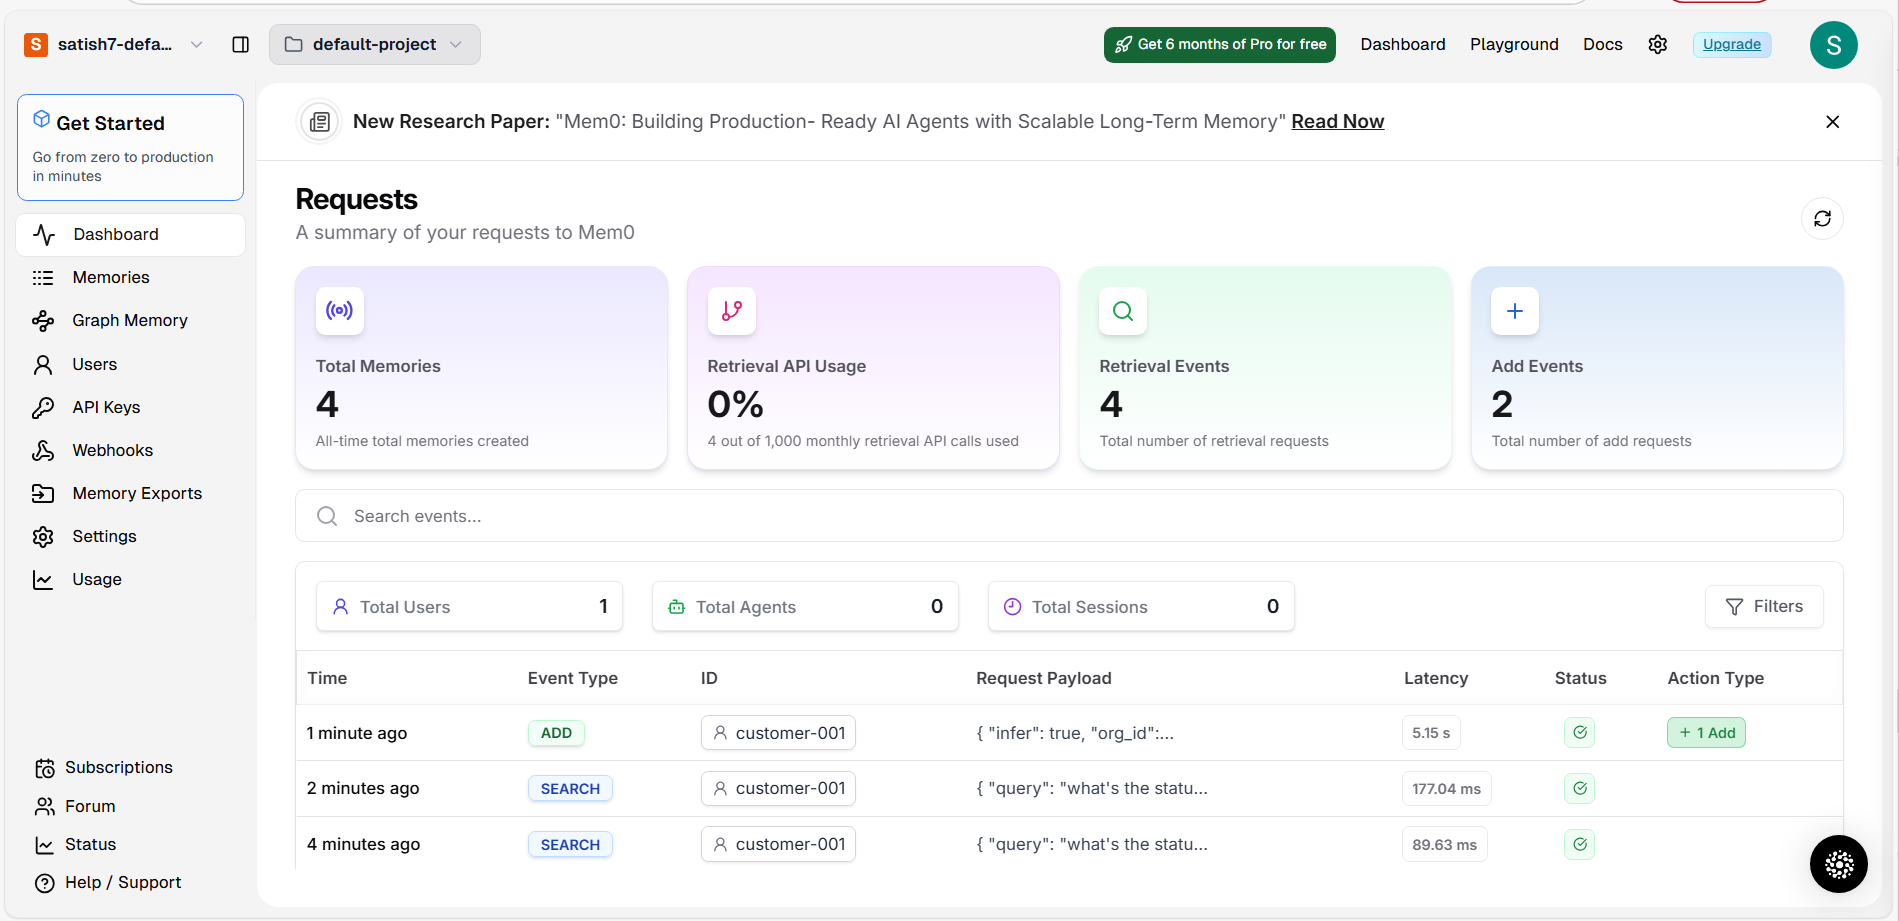 <br><br> 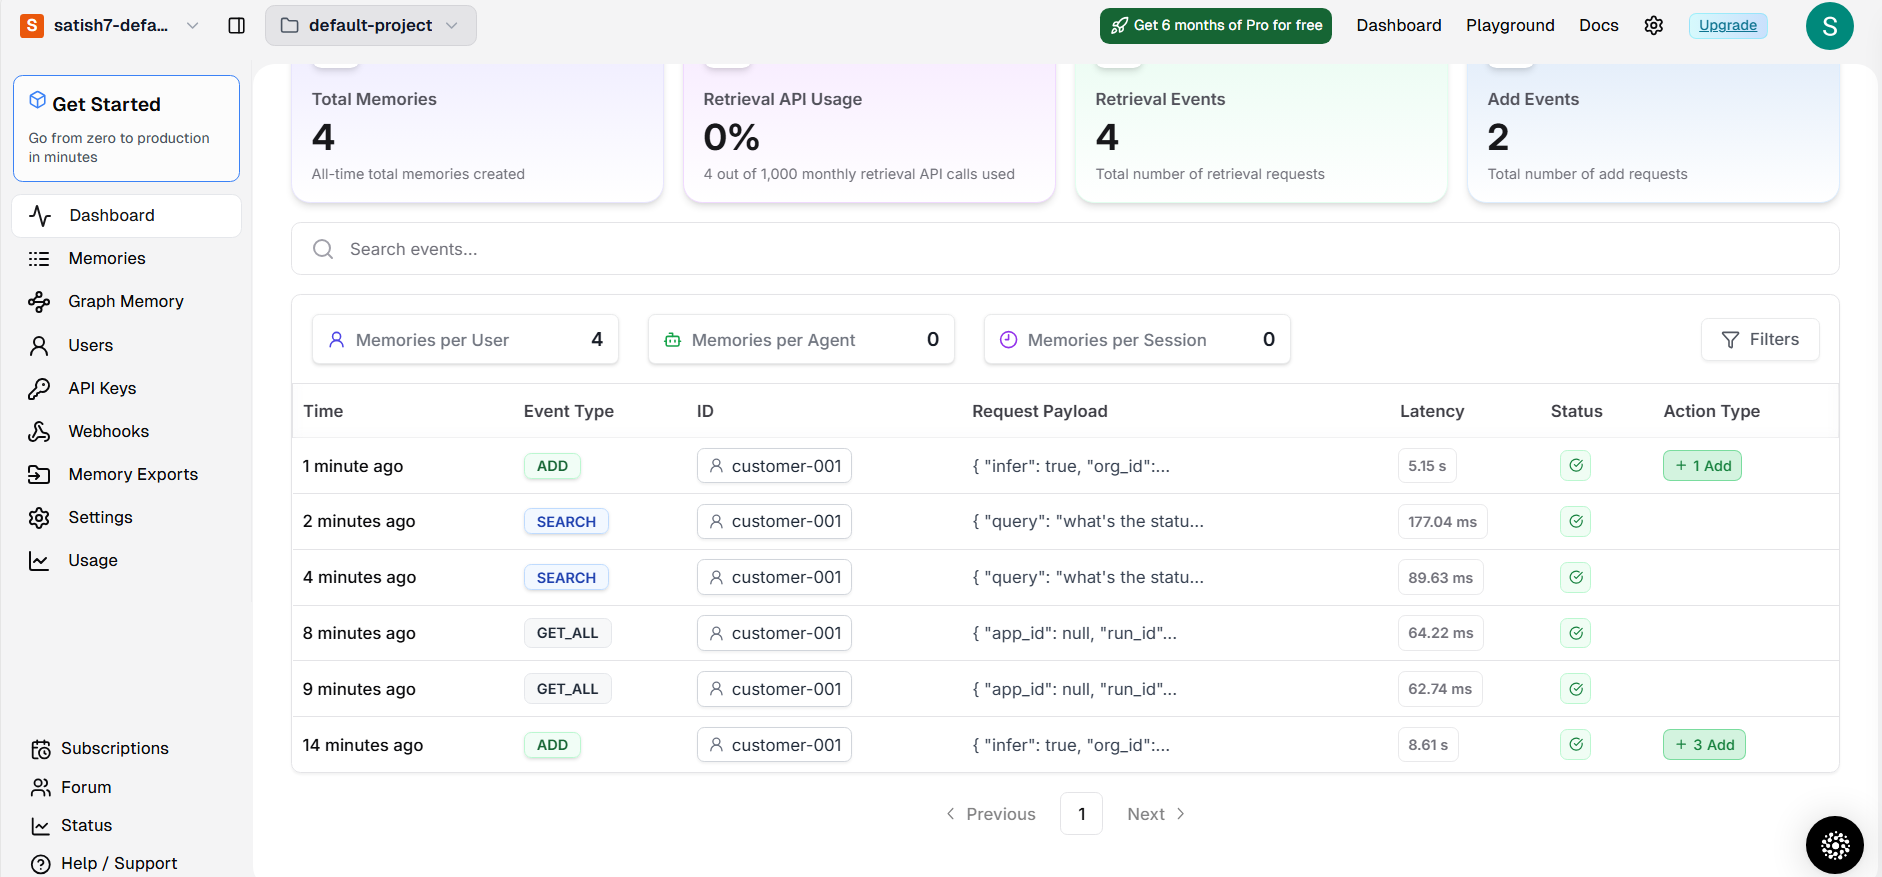 <br><br> 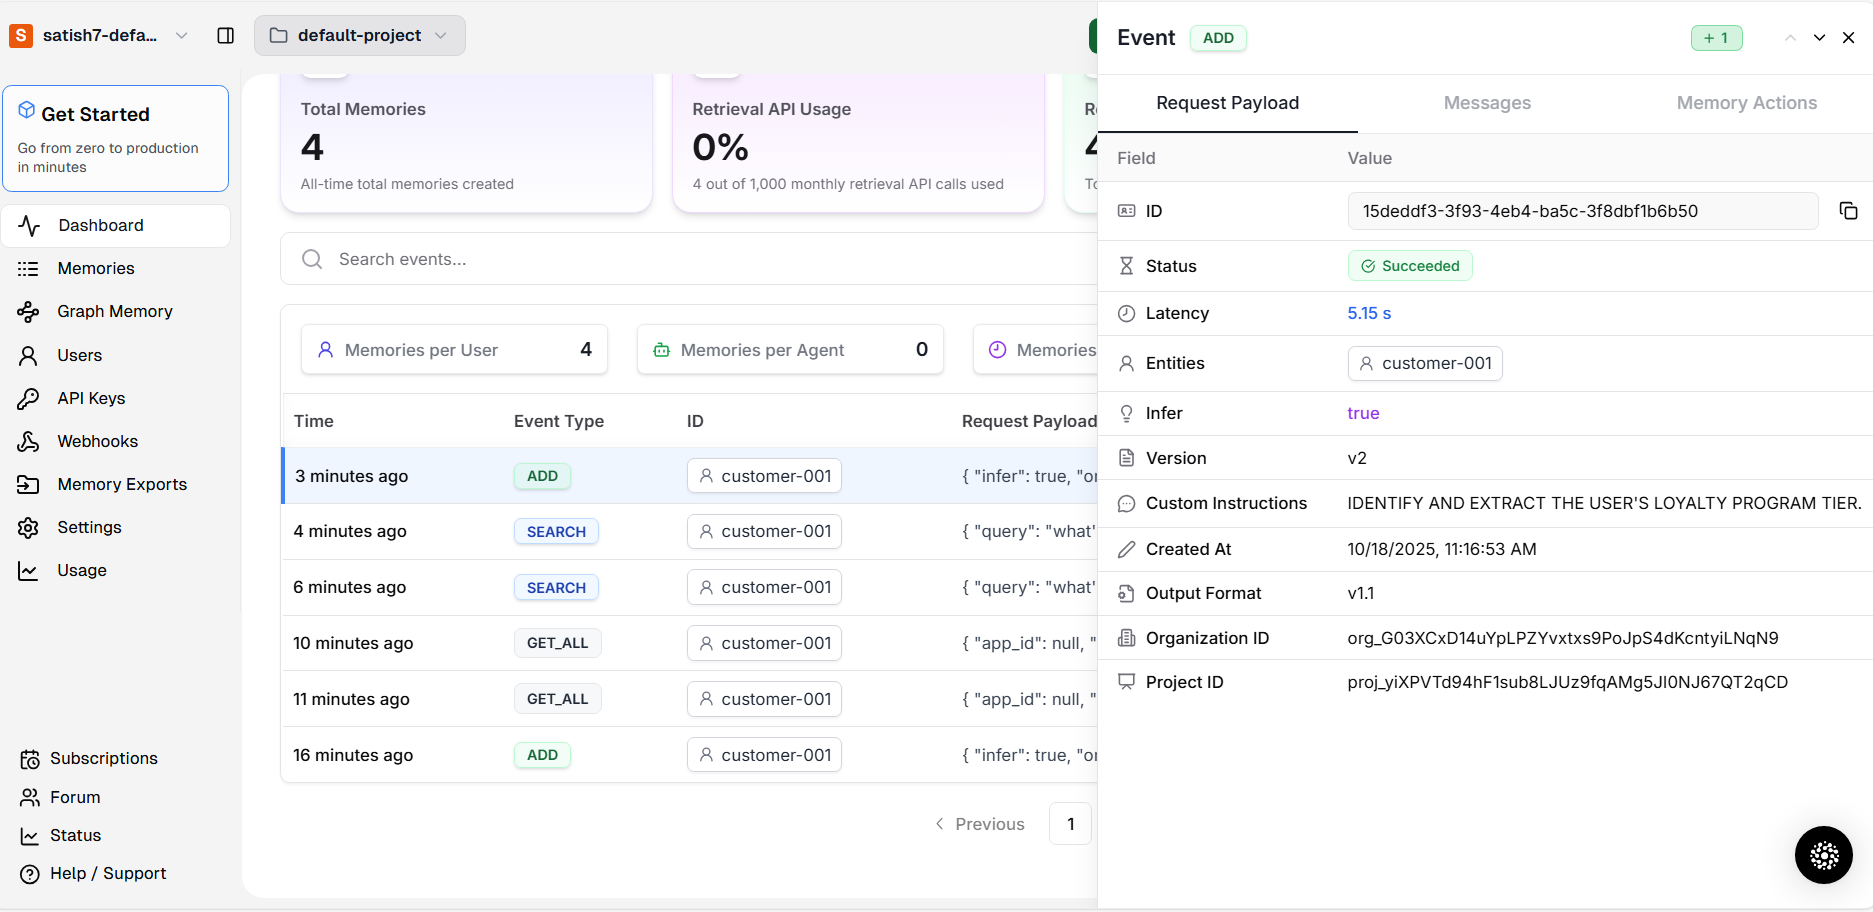 <br><br>
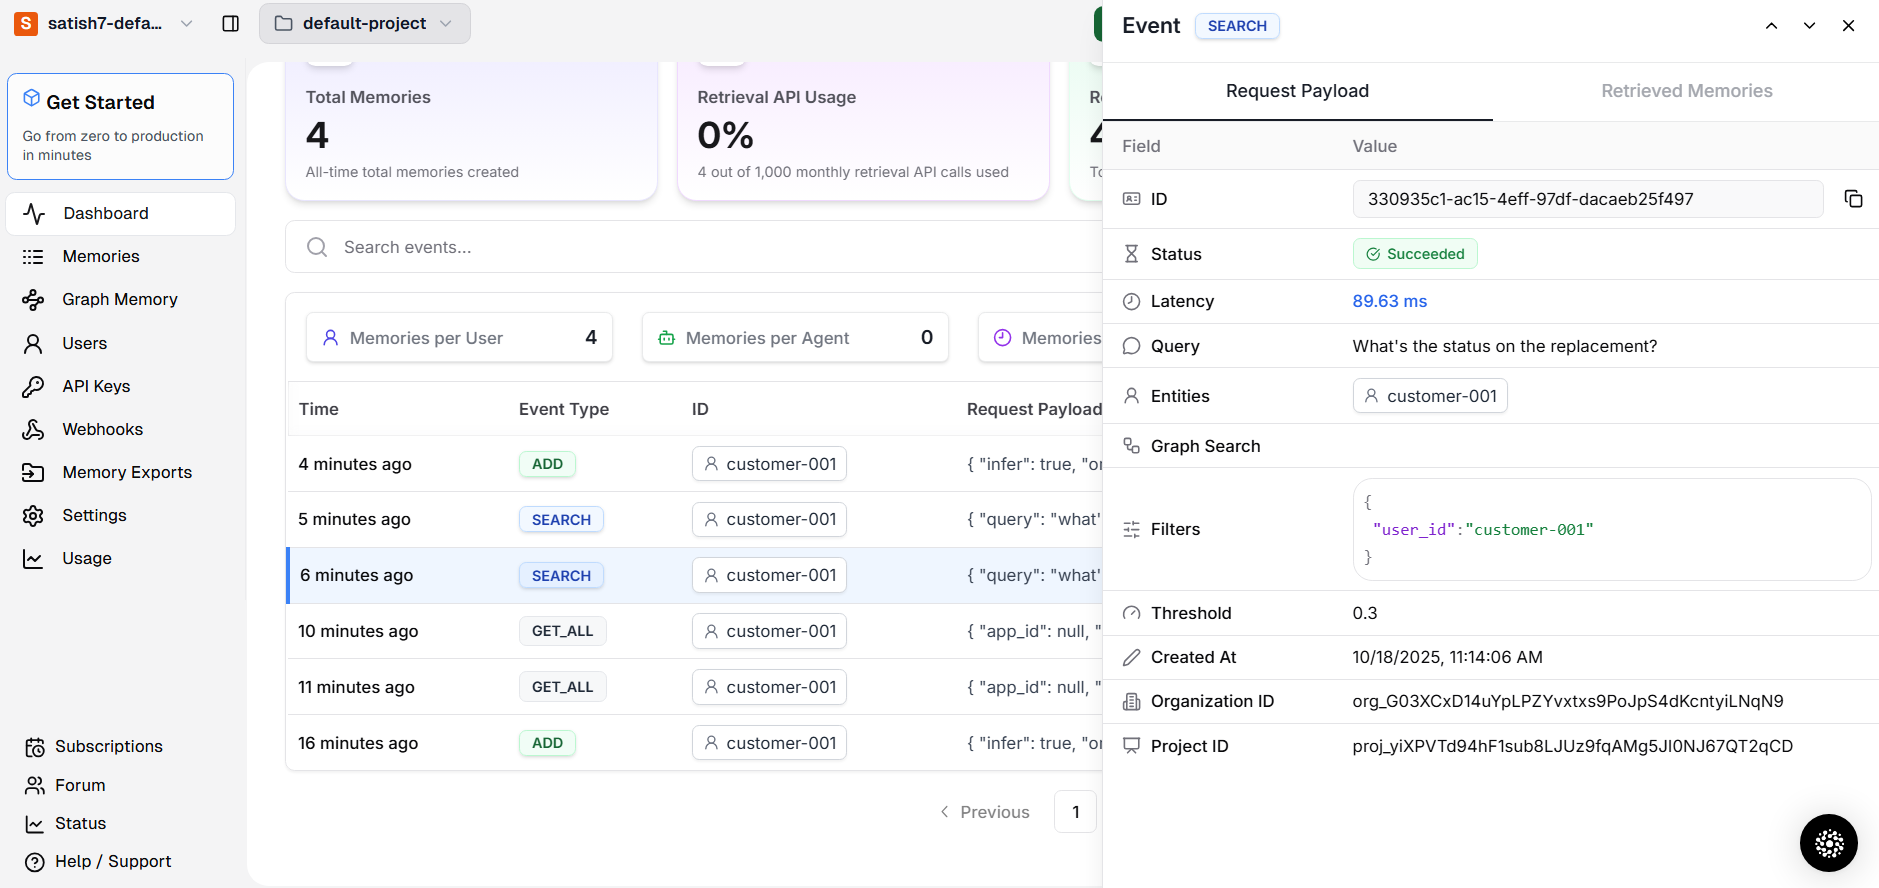 <br><br> 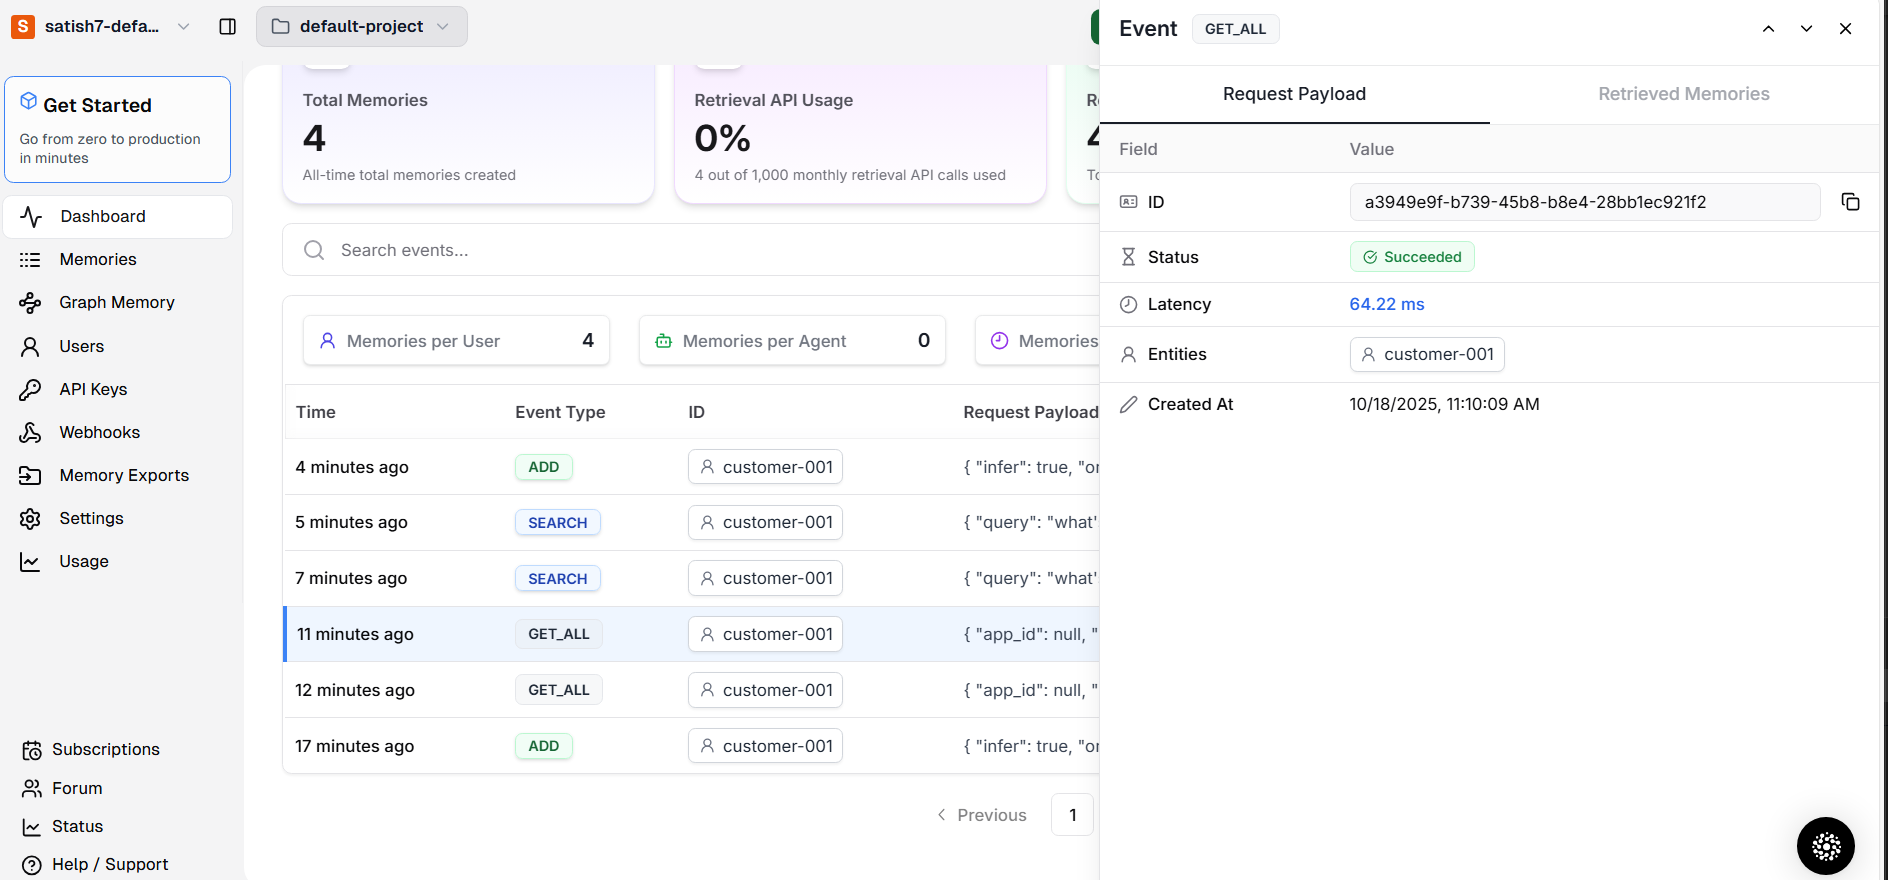 <br><br> 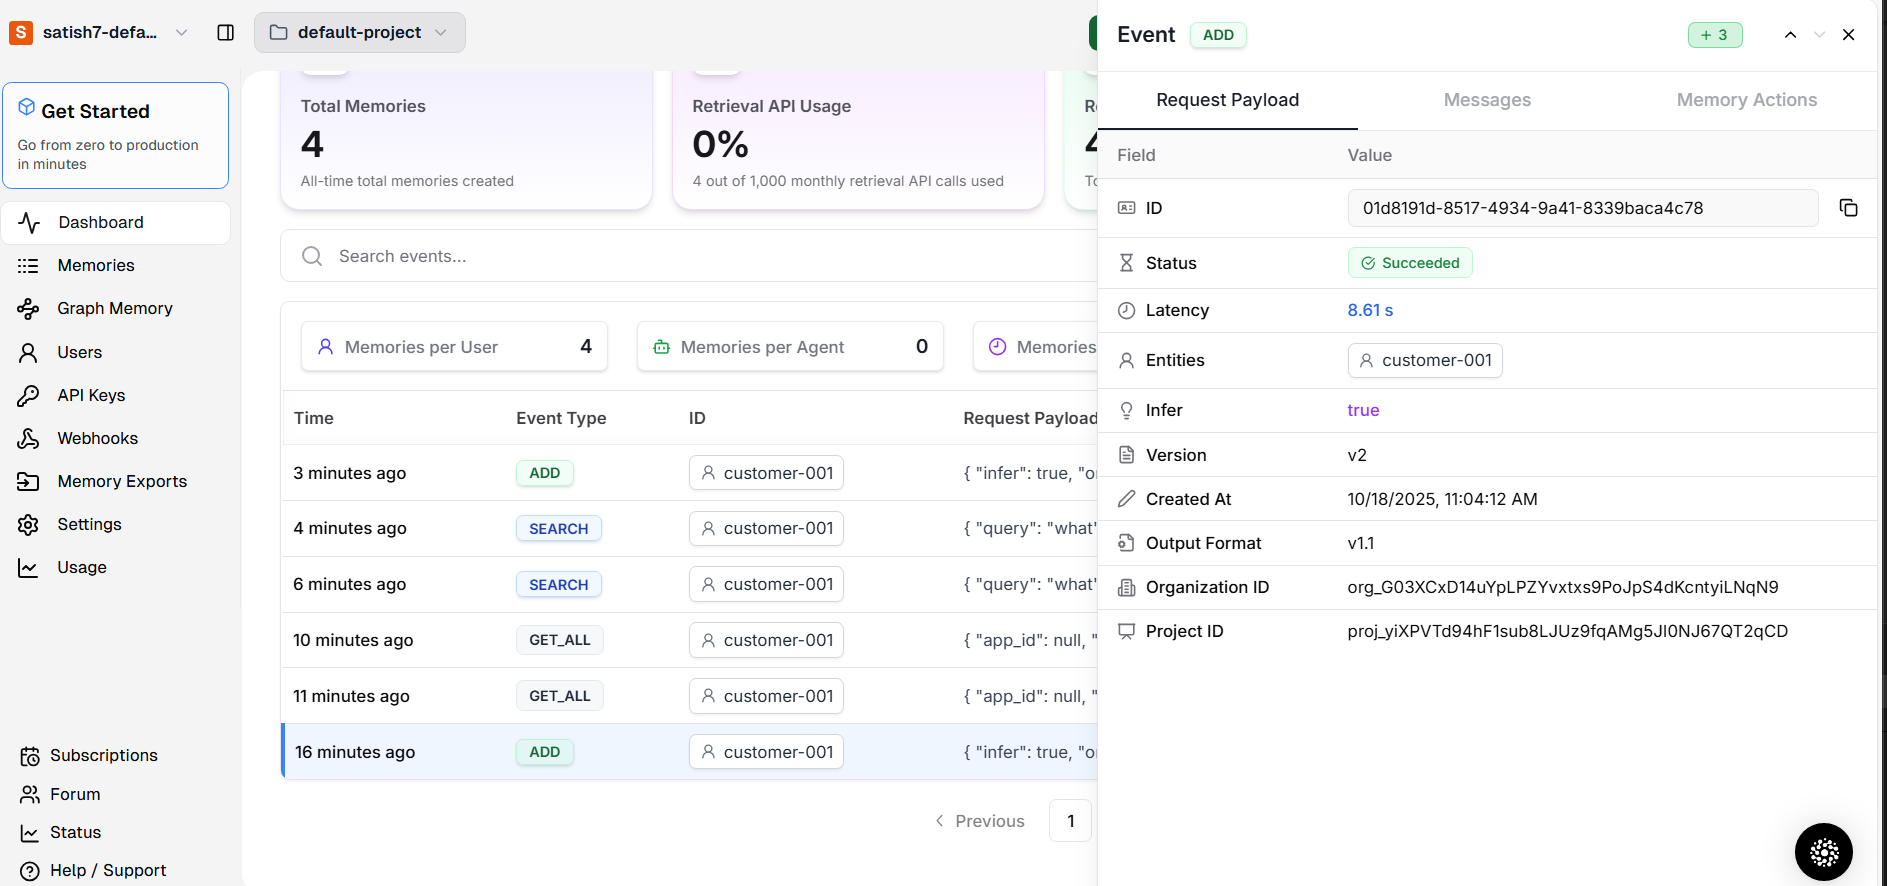 <br><br>
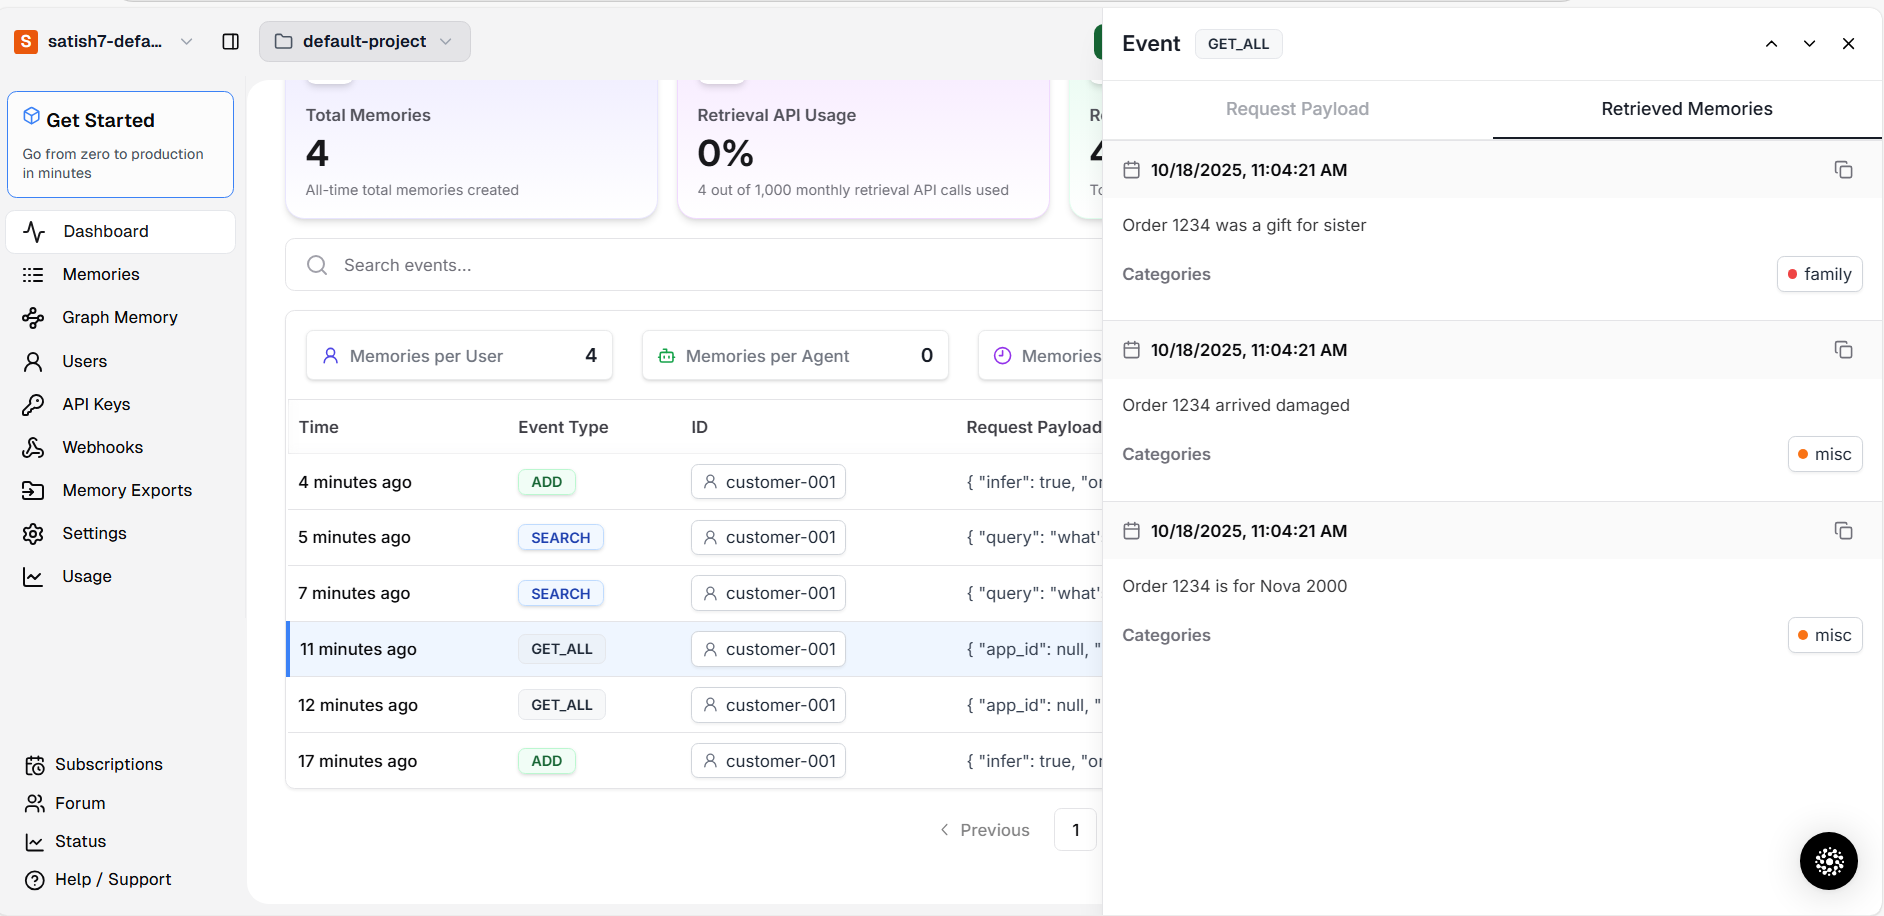 <br><br> 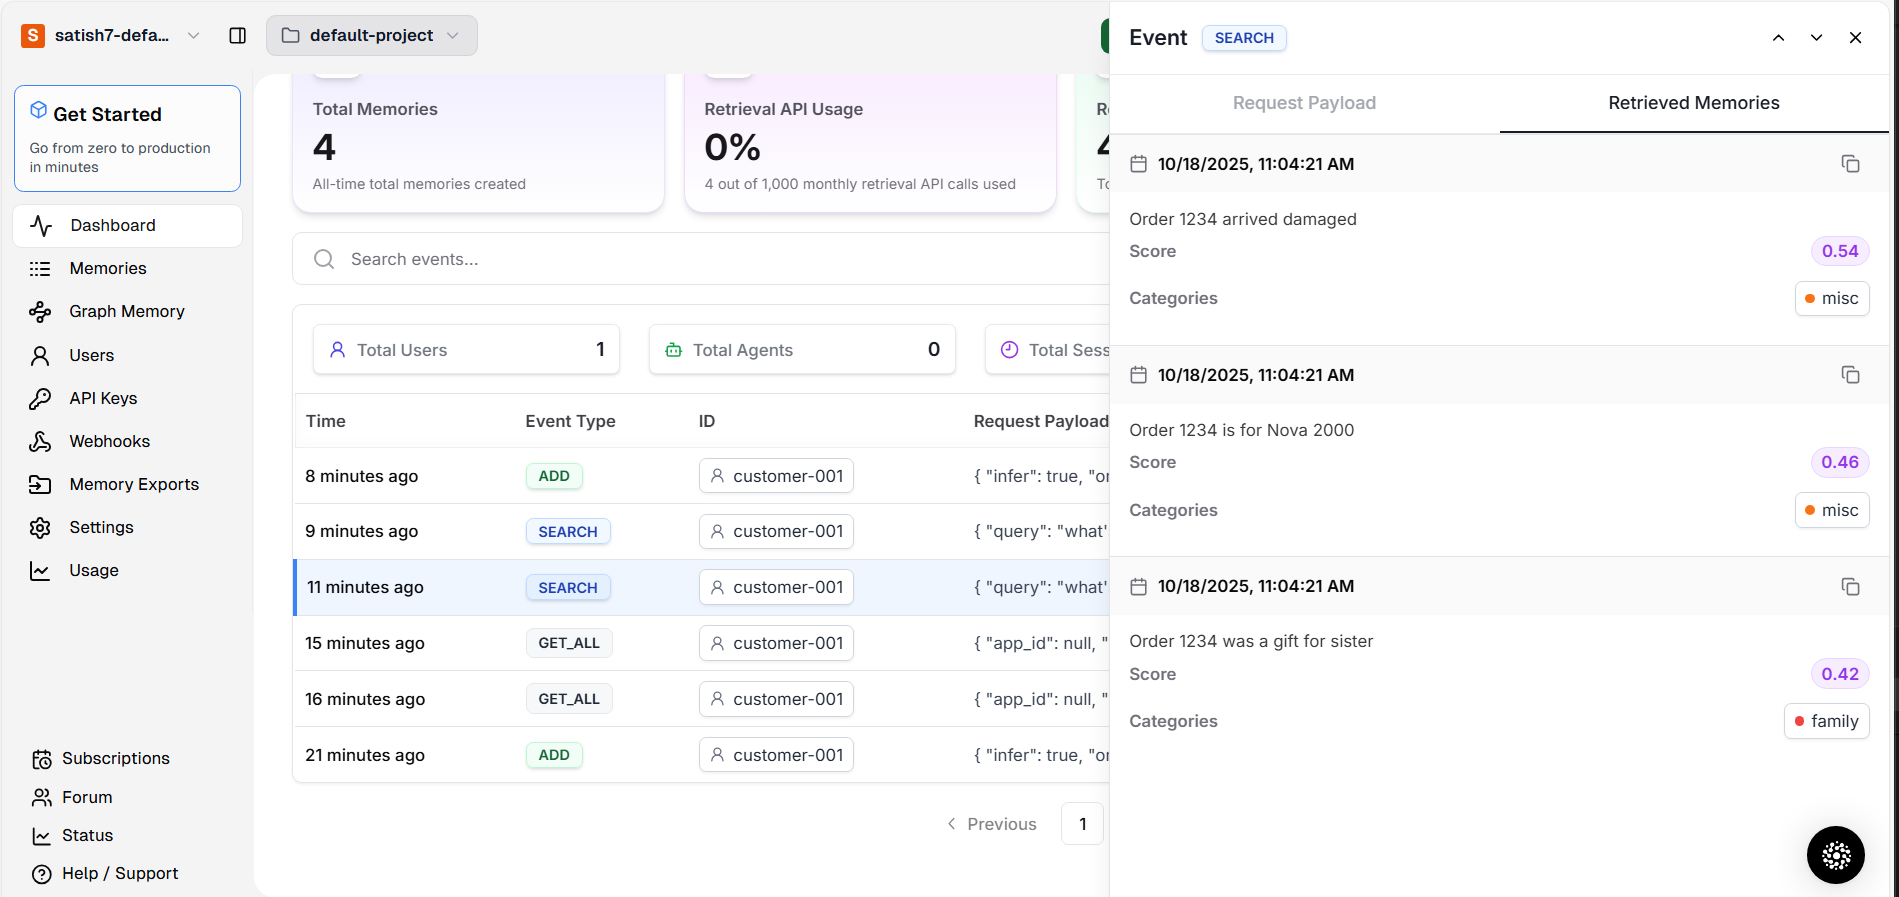 <br><br> 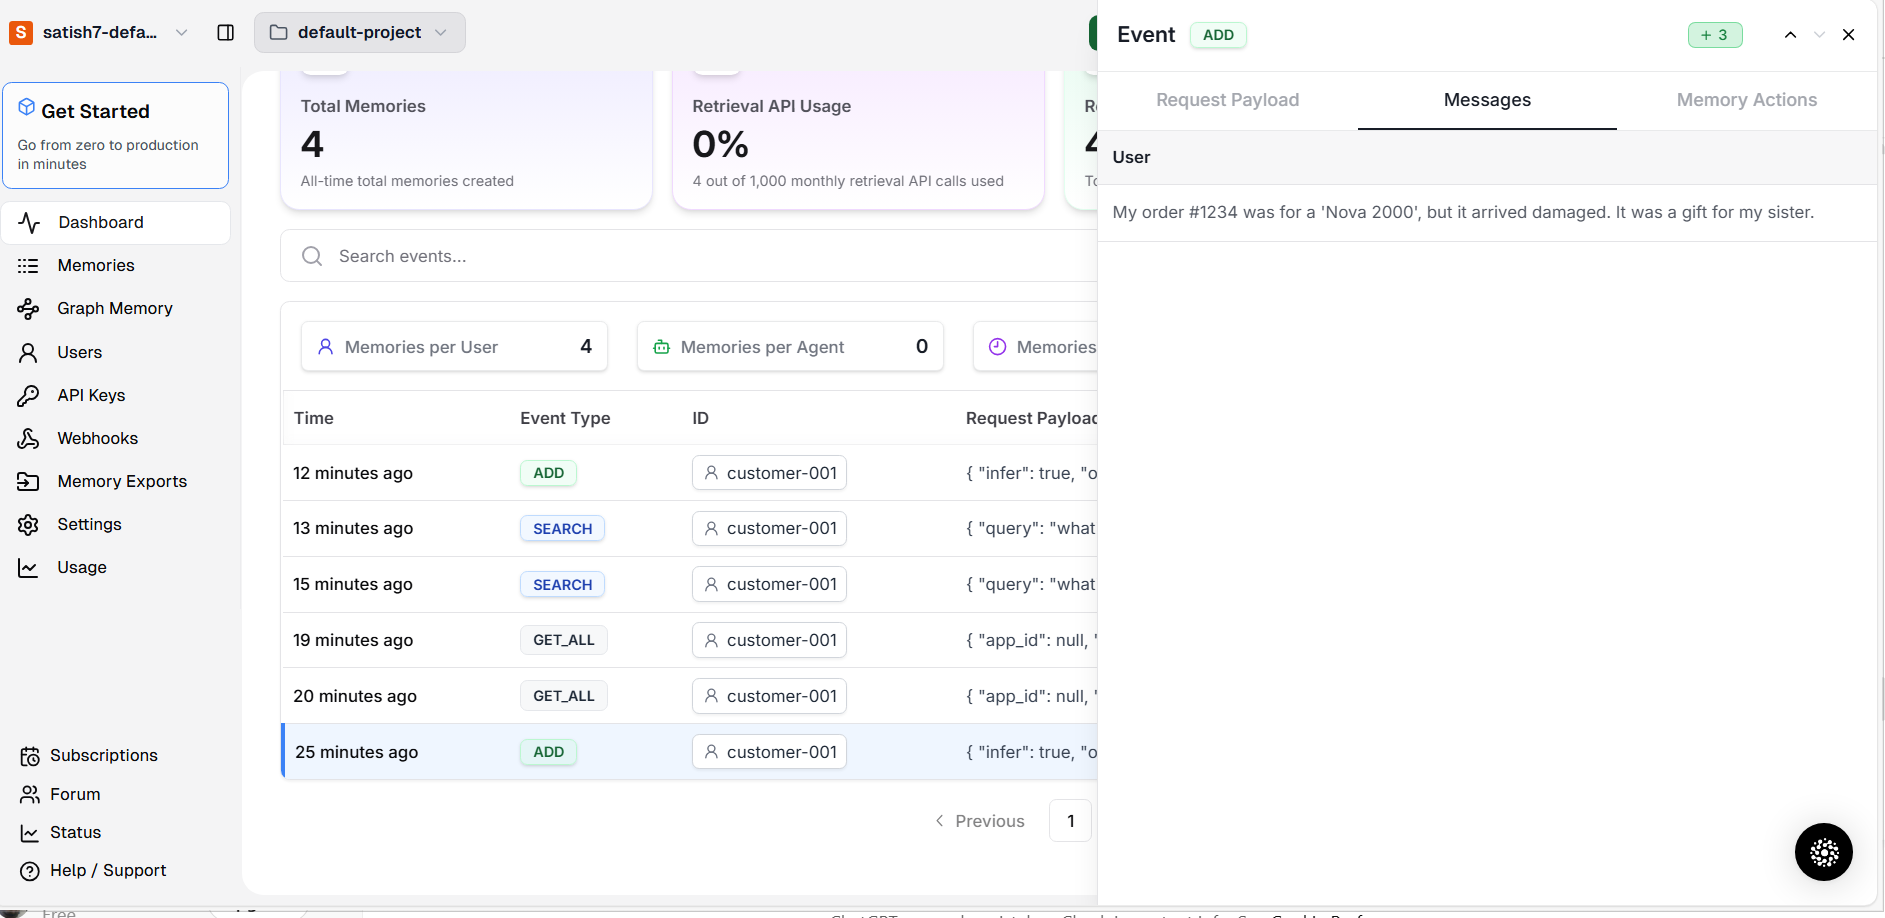 <br><br>
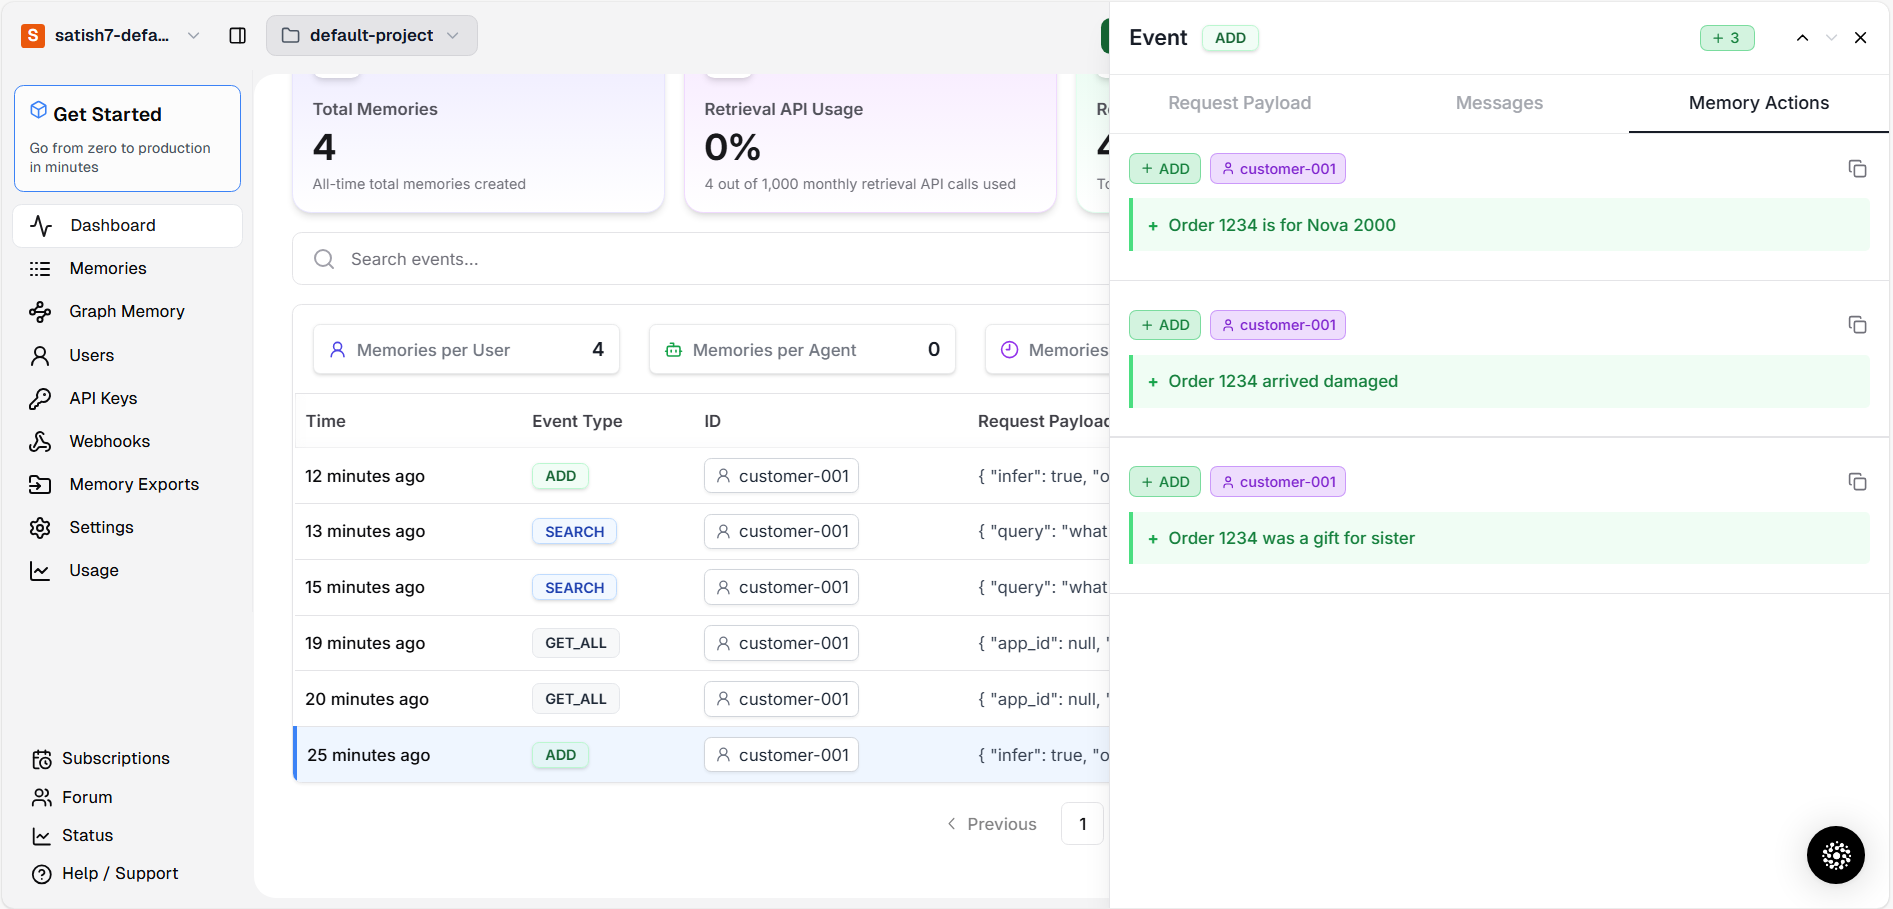

---